# Data Cleaning Pipeline & Exploratory Data Analysis

Checks for:
- Missing Values
- Duplicates
- Languages
- Length & Structure
- Outliers

Produces initial analyses for:
- engagement/controversiality KPIs
- feature correlation
- language frequencies

Saves preprocessed and augmented versions of:
- videos_df
- comments_df

In [304]:
#%pip install plotly
#%pip install statsmodels

## Select query slug and load data

In [305]:
from pathlib import Path
raw_base = Path("data/raw")

# Display all available queries:
available_queries = [
    folder.name
    for folder in raw_base.iterdir()
    if folder.is_dir()
]

print(available_queries)

['alibaba_review', 'dhl_logistik_experiences_erfahrungen', 'etsy_experiences', 'zalando_review']


In [306]:
# Select query slug:
query_slug = 'alibaba_review'

In [307]:
# Import libraries:

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import plotly.express as px
from pathlib import Path

In [308]:
# Load metadata
raw_path = Path("data/raw") / query_slug

with open(raw_path / "metadata.json") as f:
    metadata = json.load(f)

In [309]:
# Load relevant Dataframes from .csv files:

videos_df = pd.read_csv(raw_path / "videos.csv")
comments_df = pd.read_csv(raw_path / "comments.csv")

## Data overview and missing values

In [310]:
videos_df.info()
videos_df.isna() # 3 videos have no description, we still keep them for now
videos_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       50 non-null     object
 1   title          50 non-null     object
 2   description    38 non-null     object
 3   channel        50 non-null     object
 4   published_at   50 non-null     object
 5   view_count     50 non-null     int64 
 6   like_count     50 non-null     int64 
 7   comment_count  50 non-null     int64 
 8   query_origin   50 non-null     object
 9   query_slug     50 non-null     object
 10  year           50 non-null     int64 
 11  month          50 non-null     int64 
 12  calendar_week  50 non-null     int64 
 13  weekday        50 non-null     object
dtypes: int64(6), object(8)
memory usage: 5.6+ KB


,view_count,like_count,comment_count,year,month,calendar_week
count,5.000000e+01,50.000000,50.00000,50.00000,50.000000,50.00000
mean,9.022092e+05,15324.720000,218.22000,2023.74000,6.720000,26.66000
std,3.523347e+06,39940.803166,302.59094,1.70006,3.614257,15.94328
min,1.367000e+03,0.000000,8.00000,2017.00000,1.000000,1.00000
25%,2.673675e+04,307.750000,38.25000,2023.00000,4.000000,13.25000
50%,1.145160e+05,2363.000000,94.50000,2024.00000,8.000000,31.00000
75%,3.676882e+05,8383.500000,274.25000,2025.00000,9.000000,38.75000
max,2.470292e+07,195319.000000,1613.00000,2026.00000,12.000000,52.00000


In [311]:
comments_df.info()
comments_df.isna()
comments_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_id    2999 non-null   object
 1   video_id      2999 non-null   object
 2   author        2999 non-null   object
 3   text          2999 non-null   object
 4   like_count    2999 non-null   int64 
 5   published_at  2999 non-null   object
 6   reply_count   2999 non-null   int64 
 7   query_origin  2999 non-null   object
 8   query_slug    2999 non-null   object
dtypes: int64(2), object(7)
memory usage: 211.0+ KB


,like_count,reply_count
count,2999.000000,2999.000000
mean,3.260420,0.504835
std,29.357778,1.272913
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,957.000000,26.000000


In [312]:
text_columns = [
    "title",
    "description"
]
videos_df[text_columns] = (
    videos_df[text_columns]
    .fillna("")
)
comments_df["text"] = (
    comments_df["text"]
    .fillna("")
)

In [313]:
print(videos_df.dtypes)
videos_df.select_dtypes(include="object").head(10)

video_id         object
title            object
description      object
channel          object
published_at     object
view_count        int64
like_count        int64
comment_count     int64
query_origin     object
query_slug       object
year              int64
month             int64
calendar_week     int64
weekday          object
dtype: object


,video_id,title,description,channel,published_at,query_origin,query_slug,weekday
0,iUZlwfdwKmY,The UGLY Truth About Buying From Alibaba That ...,🔵Sign Up For My FREE 6 Day Ecommerce Course - ...,MyWifeQuitHerJob Ecommerce Channel,2024-04-02 13:30:31+00:00,Alibaba Review,alibaba_review,Tuesday
1,mdTrOGO6I2A,Is it SAFE to buy from Alibaba!? #southafrica ...,,STEFAN VAN DER MERWE,2023-06-20 08:17:09+00:00,Alibaba Review,alibaba_review,Tuesday
2,zJOHngd7PUI,Red Light Therapy Alibaba Review: Too Good To ...,Is buying a red light therapy panel from Aliba...,Red Light Therapy by Alex Fergus,2023-01-29 14:41:18+00:00,Alibaba Review,alibaba_review,Sunday
3,zQMQJQPzMv4,Alibaba.com Review 2025 – My Honest Buying Exp...,"In today’s video, I share my full, honest expe...",ATech Flow ®,2025-11-24 06:15:54+00:00,Alibaba Review,alibaba_review,Monday
4,EMdhDO4lhOc,5 better Alibaba alternatives #importfromchina...,,Abdel Sourcing,2024-11-10 13:23:16+00:00,Alibaba Review,alibaba_review,Sunday
5,BpUx0ghntM0,A Common Scam That You'll See On Alibaba (Don'...,,MyWifeQuitHerJob Ecommerce Channel,2022-02-11 21:01:50+00:00,Alibaba Review,alibaba_review,Friday
6,eaBZbhaOK7Y,Importing From China (Alibaba) | What I Wish I...,In this video I deep take a deep dive into the...,STEFAN VAN DER MERWE,2025-02-24 18:01:25+00:00,Alibaba Review,alibaba_review,Monday
7,nYg3pz3MDB8,How To Buy From Alibaba Safely (Without Gettin...,Take My Free Mini Course - https://mywifequith...,MyWifeQuitHerJob Ecommerce Channel,2021-07-20 13:30:19+00:00,Alibaba Review,alibaba_review,Tuesday
8,62Reyt7g__Q,Paano Maghanap ng Legit Suppliers sa Alibaba,Paano mo malalaman kung legit ang supplier sa ...,Ryan Rodrigo,2025-07-14 03:03:27+00:00,Alibaba Review,alibaba_review,Monday
9,gk69hV6LEgI,What is Alibaba? | CNBC Explains,Alibaba has become one of the world's largest ...,CNBC International,2017-09-21 09:26:51+00:00,Alibaba Review,alibaba_review,Thursday


In [314]:
# Check for duplicates:
print(videos_df["video_id"].duplicated().sum())
print(comments_df["comment_id"].duplicated().sum())

0
0


In [315]:
# Show Top10 most commented videos:

videos_df.sort_values(
    "comment_count",
    ascending=False
)[
    ["title", "comment_count"]
].head(10)

,title,comment_count
13,Forget Alibaba! Here Are 13 Better Alternative...,1613
28,This Alibaba Dirt Bike Costs Less Than an iPho...,926
37,"My experience Spending $15,000 on Alibaba Buyi...",906
7,How To Buy From Alibaba Safely (Without Gettin...,725
22,The Alibaba Car Part Iceberg ACTUALLY Explained,585
17,Ordering a Mini Excavator 2.5T from China via ...,566
9,What is Alibaba? | CNBC Explains,555
35,Alibaba Parts Cause PC Chaos!,456
23,The Cheapest Alibaba Ebike Just Got a Speed Up...,312
24,"I Bought $1,000 Worth Of Mystery Tech On Aliba...",309


In [316]:
# Show Top10 most liked videos:

videos_df.sort_values(
    "like_count",
    ascending=False
)[
    ["title", "like_count"]
].head(10)

,title,like_count
47,"Alibaba Item! New Gadgets, Smart Appliances, K...",195319
18,Snapdragon 8gen 3 Smartphone From Alibaba.com ...,155972
37,"My experience Spending $15,000 on Alibaba Buyi...",141446
13,Forget Alibaba! Here Are 13 Better Alternative...,62369
35,Alibaba Parts Cause PC Chaos!,41343
7,How To Buy From Alibaba Safely (Without Gettin...,20820
5,A Common Scam That You'll See On Alibaba (Don'...,18509
9,What is Alibaba? | CNBC Explains,14205
28,This Alibaba Dirt Bike Costs Less Than an iPho...,12977
29,30 Samples from Alibaba!,12663


In [317]:
# Discussion Activation Rate (DAR): "How strongly does the video activate its viewers to engage?"
# DAR = (comment_count + 0.3 * like_count) / view_count

videos_df["discussion_activation_rate"] = (
    (
        videos_df["comment_count"]
        + 0.3 * videos_df["like_count"]
    )
    /
    videos_df["view_count"]
)

videos_df.sort_values(
    "discussion_activation_rate",
    ascending=False
)[
    ["title", "discussion_activation_rate"]
].head(10)

,title,discussion_activation_rate
41,China’s Tech is Crazy 😲 #alibaba #quarkAI,0.030798
43,I Waited 3 Months for This Alibaba Carbon Fibe...,0.023855
44,Alibaba Bike Conversion Kit: Scam or Legit? Ho...,0.023606
32,FINDING Vendors On Alibaba For Your Online bus...,0.019212
35,Alibaba Parts Cause PC Chaos!,0.019048
37,"My experience Spending $15,000 on Alibaba Buyi...",0.018127
30,The TRUTH About Alibaba Food Trucks – My Hones...,0.016825
8,Paano Maghanap ng Legit Suppliers sa Alibaba,0.016471
38,Best websites rather then Alibaba #businessmal...,0.015689
24,"I Bought $1,000 Worth Of Mystery Tech On Aliba...",0.014205


In [318]:
# Controversy / Conversational Tension Score (CTS): 
# "How much discussion relative to agreement does the video produce?"
# CTS = log1p(comment_count) - log1p(like_count)

videos_df["controversy_tension_score"] = (
    np.log1p(videos_df["comment_count"])
    -
    np.log1p(videos_df["like_count"])
)

videos_df.sort_values(
    "controversy_tension_score",
    ascending=False
)[
    ["title", "controversy_tension_score"]
].head(10)

,title,controversy_tension_score
46,Don’t buy from Alibaba 🙄 #shorts #ps5 #tiktok,4.127134
8,Paano Maghanap ng Legit Suppliers sa Alibaba,-0.550046
43,I Waited 3 Months for This Alibaba Carbon Fibe...,-0.621920
44,Alibaba Bike Conversion Kit: Scam or Legit? Ho...,-0.700165
2,Red Light Therapy Alibaba Review: Too Good To ...,-0.793817
34,"Chinese Alibaba Camper Cap Review – The Good, ...",-0.955511
14,I Ordered Furniture From Alibaba (To Test A Th...,-1.098612
27,UPDATE / Long Term Review! I bought a Tacoma T...,-1.148623
30,The TRUTH About Alibaba Food Trucks – My Hones...,-1.228665
17,Ordering a Mini Excavator 2.5T from China via ...,-1.413264


In [319]:
# Show Top10 most replied to comments:

comments_df.sort_values(
    "reply_count",
    ascending=False
)[
    ["text", "reply_count"]
].head(10)

,text,reply_count
917,"If you enjoyed this video, then sign up for my...",26
712,Most of us tend to pay more attention to the s...,14
501,"If you enjoyed this video, make you take my fr...",14
1372,yall so lucky to live in america where shippin...,13
2905,I ordered a PS5 from Alibaba just because I ha...,13
1919,🔗 Link to the bike I bought: https://valtinsus...,11
83,The worst part of importing from China for me ...,11
157,"No, I will never trust them. I remember orderi...",11
2129,Why does bro sound and act exactly like Carter...,10
1653,30k LIKES AND I’LL BUY THE HUMAN SIZED ROBOT O...,10


In [320]:
# Show Top10 most liked comments:

comments_df.sort_values(
    "like_count",
    ascending=False
)[
    ["text", "like_count"]
].head(10)

,text,like_count
940,Suppliers do not ignore you because of pricing...,957
963,"Alibaba is great, but alternatives help divers...",853
926,i put omitren on the same level as the boutiqu...,501
400,"""Fell off a truck"" has been the excuse for sel...",331
1806,Finally Samsung and apple collaborate and form...,284
996,didn’t follow the usual LLC advice went with N...,272
2956,Is tarah ki video bana kar aap bachhe ko galat...,246
1831,It's a Sapple 14 Ultra!,243
2129,Why does bro sound and act exactly like Carter...,220
917,"If you enjoyed this video, then sign up for my...",164


### Show Boxplots for the distribution of views, likes and comments using log scale

### Display Boxplots using .melt()

C:\Users\gkahl\AppData\Local\Temp\ipykernel_44552\784933101.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




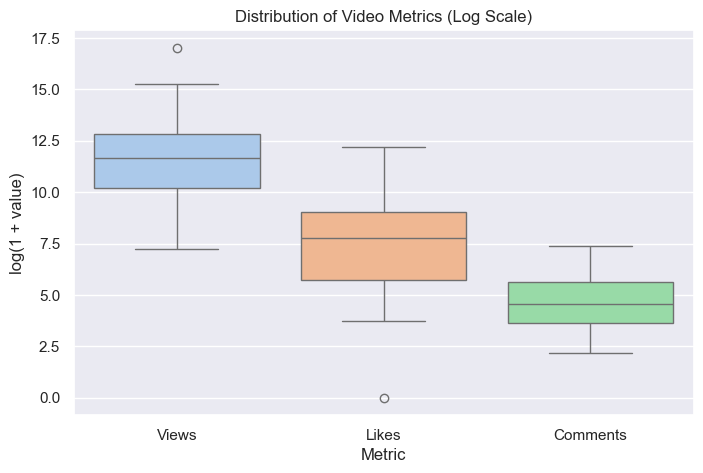

In [321]:
plot_df = pd.DataFrame({
    "Views": np.log1p(videos_df["view_count"]),
    "Likes": np.log1p(videos_df["like_count"]),
    "Comments": np.log1p(videos_df["comment_count"])
})
plot_df = plot_df.melt(
    var_name="Metric",
    value_name="Value"
)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x="Metric",
    y="Value",
    palette="pastel"
)

plt.title("Distribution of Video Metrics (Log Scale)")
plt.ylabel("log(1 + value)")

plt.show()

<Axes: >

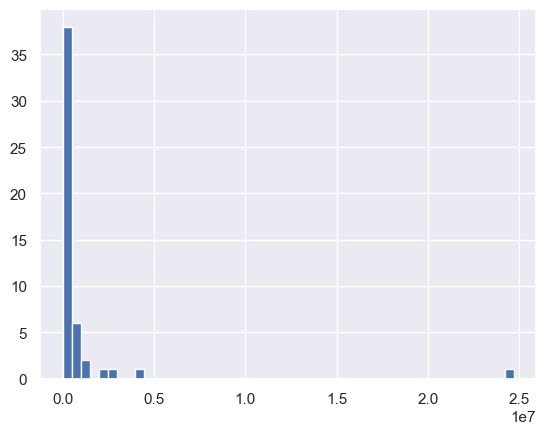

In [322]:
videos_df["view_count"].hist(bins=50)

<Axes: >

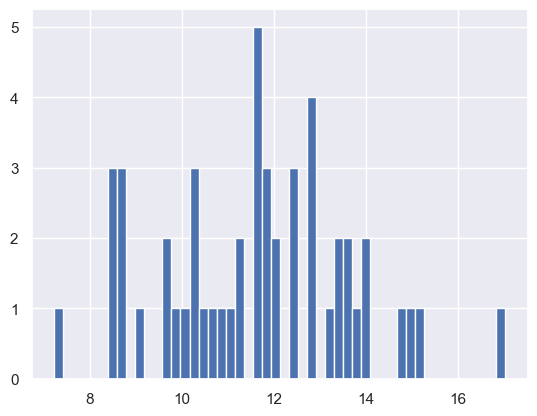

In [323]:
np.log1p(videos_df["view_count"]).hist(bins=50)

### Besides videos_df["comment_count"], which counts the number of comments on Youtube, we can also look at the number of comments that we have in our database for each of our videos.

In [324]:
comments_per_video = (
    comments_df
    .groupby("video_id")
    .size()
)

merged = comments_df.merge(
    videos_df,
    on="video_id",
    how="left"
)

merged.groupby("title").size().sort_values(ascending=False)

title
China’s Tech is Crazy 😲 #alibaba #quarkAI                                                               100
How To Buy From Alibaba Safely (Without Getting Scammed)                                                100
Forget Alibaba! Here Are 13 Better Alternatives To Find Wholesale Suppliers                             100
First real customer review–  Tiny House DIY! Ali Baba & MadeInChina.com | Cheapest House?               100
FINDING Vendors On Alibaba For Your Online business #alibaba #onlibusiness ine                          100
Snapdragon 8gen 3 Smartphone From Alibaba.com China - ₹5000 Only                                        100
Importing From China (Alibaba) | What I Wish I Knew: Shipping Agent Edition                             100
The Alibaba Car Part Iceberg ACTUALLY Explained                                                         100
Best websites rather then Alibaba #businessmalayalam #dropshippingmalayalam #dropshipping2025           100
Avoid Alibaba Scams: T

# Exploratory Data Analysis: 

## How has engagement developed over time?

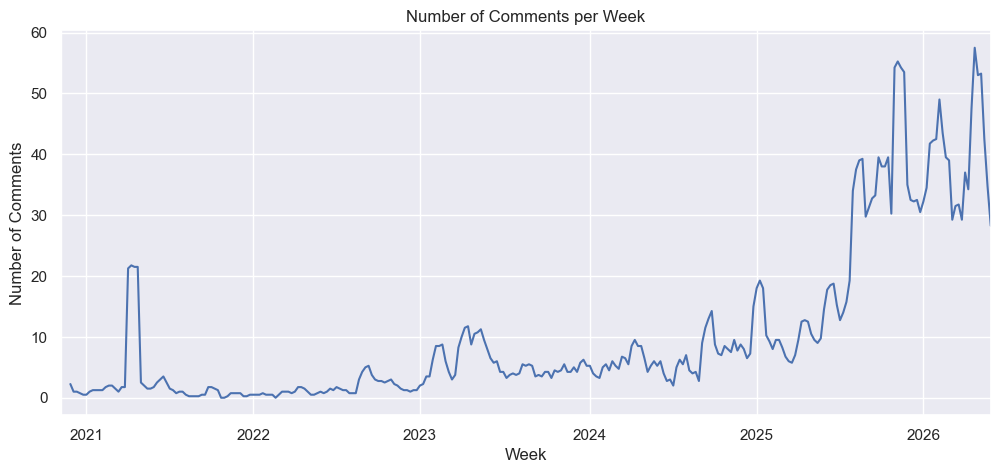

In [325]:
# Plot the comments over time

comments_df["published_at"] = pd.to_datetime(
    comments_df["published_at"]
)

comments_per_week = (
    comments_df
    .set_index("published_at")
    .resample("W")
    .size()
)

comments_per_week_smooth = (
    comments_per_week
    .rolling(4)
    .mean()
)

sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 5))

comments_per_week_smooth.plot()

plt.title("Number of Comments per Week")
plt.xlabel("Week")
plt.ylabel("Number of Comments")

plt.show()

## How are comments and likes correlated?

In [326]:
videos_df["log_like_count"] = np.log1p(
    videos_df["like_count"]
)

videos_df["log_comment_count"] = np.log1p(
    videos_df["comment_count"]
)

fig = px.scatter(
    videos_df,

    x="log_like_count",
    y="log_comment_count",


    hover_data=[
        "title"
    ],

    trendline="ols",

    title="Likes vs Comments (Log Scale)"
)

fig.show()

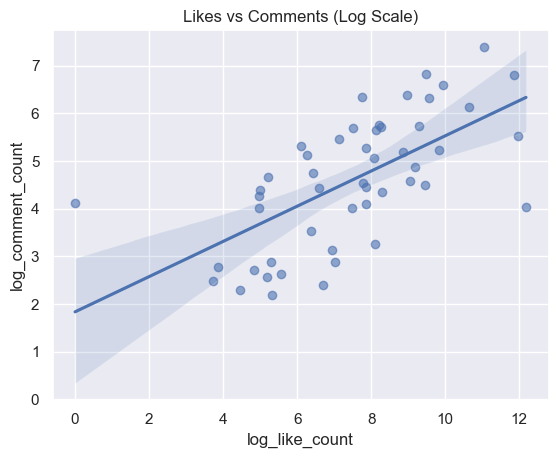

In [327]:
sns.regplot(
    data=videos_df,
    x="log_like_count",
    y="log_comment_count",
    scatter_kws={"alpha": 0.6}
)

plt.title("Likes vs Comments (Log Scale)")

plt.show()

In [328]:
# Log/log-Correlation between likes and comments
videos_df[
    ["log_like_count", "log_comment_count"]
].corr()

,log_like_count,log_comment_count
log_like_count,1.000000,0.639422
log_comment_count,0.639422,1.000000


In [329]:
videos_df[
    ["log_like_count", "log_comment_count"]
].corr(method="spearman")

,log_like_count,log_comment_count
log_like_count,1.000000,0.692079
log_comment_count,0.692079,1.000000


## Language detection and distribution (comments)

In [330]:
#%pip install langdetect
from langdetect import detect

In [331]:
def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"
    
comments_df["language"] = (
    comments_df["text"]
    .apply(detect_language)
)

comments_df["language"].value_counts(normalize=True)

language
en         0.768256
tl         0.059020
so         0.023341
unknown    0.021674
id         0.010003
af         0.010003
cy         0.008670
it         0.006335
nl         0.006002
sw         0.006002
fr         0.005669
et         0.005669
ca         0.005335
de         0.005335
no         0.004668
pt         0.004668
tr         0.004668
es         0.004335
da         0.004335
ro         0.003668
hr         0.003668
sv         0.003001
pl         0.003001
ar         0.002668
lt         0.002668
ml         0.002334
cs         0.002334
fi         0.002334
sl         0.002001
sk         0.001667
hu         0.001667
sq         0.001000
fa         0.001000
lv         0.000333
ur         0.000333
he         0.000333
ru         0.000333
hi         0.000333
vi         0.000333
zh-cn      0.000333
bg         0.000333
kn         0.000333
Name: proportion, dtype: float64

In [332]:
videos_df["language"] = (
    videos_df["title"]
    .apply(detect_language)
)

print("The top video languages are:")
videos_df["language"].value_counts(normalize=True)

The top video languages are:


language
en    0.84
tl    0.08
ca    0.04
de    0.02
af    0.02
Name: proportion, dtype: float64

In [333]:
# The top 5 languages in the comments are:
print("The top 5 languages in the comments are:")
comments_df["language"].value_counts().head(5)

The top 5 languages in the comments are:


language
en         2304
tl          177
so           70
unknown      65
id           30
Name: count, dtype: int64

C:\Users\gkahl\AppData\Local\Temp\ipykernel_44552\152886499.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




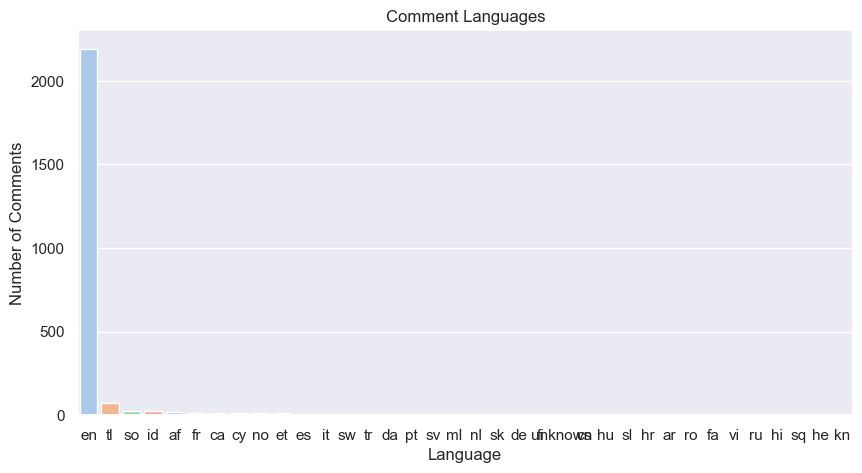

In [334]:
comments_df["text_length"] = (
    comments_df["text"]
    .astype(str)
    .str.len()
)

# Only consider comments with more than 15 characters to make the presentation more meaningful
language_df = comments_df[
    comments_df["text_length"] > 15
].copy()

sns.set_theme(style="darkgrid")

language_counts = (
    language_df["language"]
    .value_counts()
    .reset_index()
)

language_counts.columns = [
    "language",
    "count"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=language_counts,
    x="language",
    y="count",
    palette="pastel"
)

plt.title("Comment Languages")
plt.xlabel("Language")
plt.ylabel("Number of Comments")

plt.show()

In [335]:
# Separate Dataframes for languages de and en:

#comments_de = comments_df[
#    comments_df["language"].isin(["de"])
#]
#comments_en = comments_df[
#    comments_df["language"].isin(["en"])
#]

In [336]:
# Which language gets the most likes on comments?
comments_df.groupby("language")[
    "like_count"
].mean().sort_values(ascending=False)

language
id         8.466667
en         3.849392
cy         3.730769
tr         3.642857
ml         3.428571
fi         2.714286
ro         2.181818
vi         2.000000
ar         2.000000
fa         2.000000
kn         2.000000
lt         1.625000
it         1.315789
unknown    1.292308
sw         1.277778
fr         1.000000
af         0.966667
tl         0.790960
et         0.705882
no         0.571429
sl         0.500000
so         0.428571
cs         0.428571
hu         0.400000
es         0.384615
ca         0.375000
de         0.312500
pt         0.285714
pl         0.111111
nl         0.111111
sv         0.111111
hr         0.090909
da         0.000000
ur         0.000000
bg         0.000000
ru         0.000000
sq         0.000000
sk         0.000000
lv         0.000000
he         0.000000
hi         0.000000
zh-cn      0.000000
Name: like_count, dtype: float64

## Let us now produce cleaned comment data for RAG applications:

In [337]:
# Copy the comments df:
comments_clean = comments_df.copy()

# Drop empty comments:
comments_clean = comments_clean.dropna(subset=["text"])
# Save text as string:
comments_clean["text"] = comments_clean["text"].astype(str)
# Drop duplicates:
comments_clean = comments_clean.drop_duplicates(subset=["comment_id"])
# Drop very short comments:
comments_clean["text_length"] = comments_clean["text"].str.len()
comments_clean = comments_clean[comments_clean["text_length"] >= 15]
# Consider only German and English comments:
comments_clean = comments_clean[comments_clean["language"].isin(["de", "en"])]

In [338]:

def clean_text(text):

    text = text.lower()

    # URLs entfernen
    text = re.sub(r"http\S+", "", text)

    # Mehrfache Whitespaces
    text = re.sub(r"\s+", " ", text)

    # Trim
    text = text.strip()

    return text

In [339]:
comments_clean["clean_text"] = comments_clean["text"].apply(clean_text)
comments_clean = comments_clean[comments_clean["clean_text"].str.len() > 0]
comments_clean.info()
comments_clean.sample(10)[["text", "clean_text"]]

<class 'pandas.core.frame.DataFrame'>
Index: 2210 entries, 0 to 2998
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   comment_id    2210 non-null   object             
 1   video_id      2210 non-null   object             
 2   author        2210 non-null   object             
 3   text          2210 non-null   object             
 4   like_count    2210 non-null   int64              
 5   published_at  2210 non-null   datetime64[ns, UTC]
 6   reply_count   2210 non-null   int64              
 7   query_origin  2210 non-null   object             
 8   query_slug    2210 non-null   object             
 9   language      2210 non-null   object             
 10  text_length   2210 non-null   int64              
 11  clean_text    2210 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(3), object(8)
memory usage: 224.5+ KB


,text,clean_text
1845,I simply don’t use it because fuck china,i simply don’t use it because fuck china
1522,Hello everyone Just wanted to tell you all tha...,hello everyone just wanted to tell you all tha...
693,The buying opportunity of a lifetime right now,the buying opportunity of a lifetime right now
1014,I produce printable USPS shipping label for e-...,i produce printable usps shipping label for e-...
410,The maritime logistics side of importing from ...,the maritime logistics side of importing from ...
1734,so no one noticed the Amazon box on the Alibab...,so no one noticed the amazon box on the alibab...
223,Does it have the screw holes in the back so yo...,does it have the screw holes in the back so yo...
185,U sound like a shill bro get to the review,u sound like a shill bro get to the review
2503,The people who say alibaba is like some less t...,the people who say alibaba is like some less t...
2104,White Carter PCs lol,white carter pcs lol


## Save cleaned data in "processed" repository

In [340]:
from datetime import datetime

processed_path = Path("data/processed") / query_slug

processed_path.mkdir(parents=True, exist_ok=True) 

metadata = {
    "query_slug": query_slug,
    "processed_at": datetime.now().isoformat(),
    "language_filter": ["de", "en"],
    "duplicates_removed": True,
    "clean_text_created": True,
}

# Save metadata: 
with open(processed_path / "metadata.json", "w") as f: #"w" means write mode, file is being written 
    json.dump(metadata, f, indent=4) 
    
comments_clean.to_csv( 
    processed_path / "comments_clean.csv", 
    index=False 
    ) 

videos_df.to_csv(
    processed_path / "videos_clean.csv", 
    index=False 
    )

In [341]:
videos_df.columns

Index(['video_id', 'title', 'description', 'channel', 'published_at',
       'view_count', 'like_count', 'comment_count', 'query_origin',
       'query_slug', 'year', 'month', 'calendar_week', 'weekday',
       'discussion_activation_rate', 'controversy_tension_score',
       'log_like_count', 'log_comment_count', 'language'],
      dtype='object')